<a href="https://colab.research.google.com/github/ck1894/NYU-Tandon-CS-GY-6923-Machine-Learning/blob/main/week5_lab4_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 4: Fitting an MLP to regression data

In this lab, you will implement and a train a simple neural network in PyTorch. Then, you will study how the function approximation capabilities of this model are affected by the model width and depth.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

Let's create some regression data using a complicated function. There will be no test data, just the train set that we will try to fit.

Text(0, 0.5, 'y')

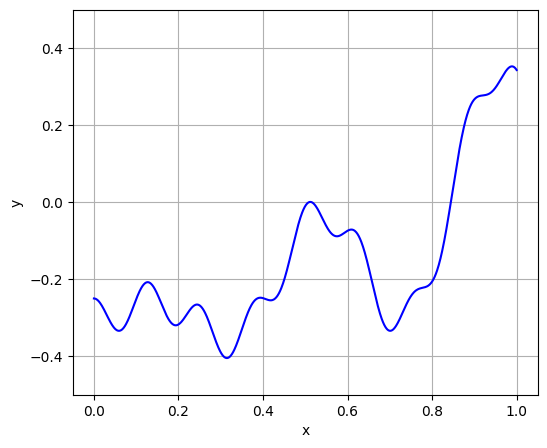

In [2]:
def f(x):
  return 0.2 + 0.4 * x**2 + 0.3 * x * torch.sin(15 * x)+ 0.05 * torch.cos(50*x) - 0.5

x = torch.linspace(0, 1, 1000)
fs = f(x)

_, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x, fs, "-b")
ax.grid()
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")


Complete the function below. See the docstring for detailed instructions. Make sure that the training works and you get a reasonable fit when you run the function with the provided parameters.

In [10]:
def train_model(
    x: torch.Tensor,
    y: torch.Tensor,
    width: int,
    num_hidden_layers: int,
    epochs: int = 1000,
    activation=nn.ReLU,
    lr: float=0.01,
    ):
  """
    Train a fully connected neural network for regression tasks using PyTorch.

    This function constructs a feedforward neural network with a specified architecture,
    trains it using the Adam optimizer and mean squared error loss, and returns both
    the trained model and its predictions on the input data.

    Architecture:
        - Input layer: Linear(1, width) → Activation
        - Hidden layers: [Linear(width, width) → Activation] × num_hidden_layers
        - Output layer: Linear(width, 1) (no activation)

    The network expects 1-dimensional input features and produces scalar outputs.

    Parameters
    ----------
    x : torch.Tensor
        Input training data of shape (n_samples, 1) or (n_samples,).
        Each sample should contain a single feature value.

    y : torch.Tensor
        Target training labels of shape (n_samples,).
        Ground truth values for the regression task.

    width : int
        Number of neurons in each hidden layer.

    num_hidden_layers : int
        Number of hidden layers in the network (not counting input/output layers).

    epochs : int, optional (default=1000)
        Number of complete passes through the training dataset.

    activation : torch.nn.Module class, optional (default=nn.ReLU)
        Activation function class to use after each linear layer except the output.
        Common choices: nn.ReLU, nn.Sigmoid, nn.Tanh, nn.LeakyReLU.
        Should be passed as a class (not an instance), e.g., nn.ReLU, not nn.ReLU().

    lr : float, optional (default=0.01)
        Learning rate for the Adam optimizer.

    Returns
    -------
    model : torch.nn.Sequential
        The trained neural network model in evaluation mode. Can be used for
        inference on new data via model(new_x).

    final_pred : torch.Tensor
        Model predictions on the input data x, detached from the computation graph.
        Shape: (n_samples,). Useful for immediate visualization or evaluation.

    Training Details
    ----------------
    - Optimizer: Adam
    - Loss function: Mean Squared Error (MSE)

  """

  # Preprocessing
  x = x.reshape(-1, 1)
  y = y.reshape(-1, 1)

  # Create model with given architecture

    # can’t put a for loop directly inside nn.Sequential(...)
    # nn.Sequential expects modules, not Python control flow
    # model = nn.Sequential(
    #     nn.Linear(1, width),
    #     activation(),
    #     for _ in range(num_hidden_layers):
    #       nn.Linear(width, width),
    #       activation()
    #     nn.Linear(width, 1)
    # )

  layers = []

  # Input layer
  layers.append(nn.Linear(1, width))
  layers.append(activation())

  # Hidden layers
  for _ in range(num_hidden_layers -1): # "-1" because we already created the first hidden layer with the input layer
    layers.append(nn.Linear(width,width))
    layers.append(activation())

  # Output layer
  layers.append(nn.Linear(width,1))

  model = nn.Sequential(*layers) # *list unpacks the list into positional arguments
  print(model)

  # Train
  model.train() # switch model to training mode
  optimizer = optim.Adam(model.parameters(), lr=lr)
  criterion = nn.MSELoss()

  for epoch in range(epochs):
    # Forward pass
        # predictions and loss are computed based on the previous iteration (optimizer.step())
        # last loss is usually ignored - it's fine because we have many epochs and loss converges
    y_pred = model(x)
    loss = criterion(y_pred, y)

    # Backward pass
    optimizer.zero_grad() # Reset gradients to zero.
                          # Important for iterations because PyTorch "accumulates" (does not overwrite) gradients by default.
    loss.backward() # Backpropagation: compute ∂loss / ∂𝜃 (gradients) for all model parameters
    optimizer.step() # Update model weights
#    print(f"Epoch #{epoch}, Loss={loss.item():.4f}")

  # Prediction (will be returned)
  model.eval() # Switch model to evaluation mode
  with torch.no_grad():     # This tells PyTorch to not build the computational graph or track gradients.
                            # This ensures we are only making predictions, not learning.
    final_pred = model(x)                  # Runs a forward pass on test data.

  return model, final_pred

Sequential(
  (0): Linear(in_features=1, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=1, bias=True)
)


Text(0, 0.5, 'y')

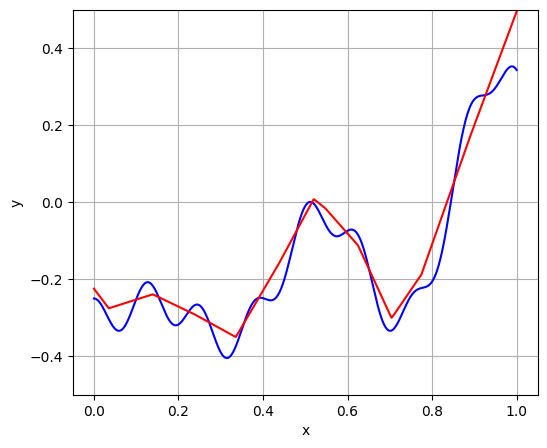

In [11]:
_, y_pred = train_model(x[:, None], fs, width=256, num_hidden_layers=1)


_, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x, fs, "-b")
ax.plot(x, y_pred, "-r")
ax.grid()
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")

Now, try the following values of width and depth:
- `num_hidden_layers in [1, 3]`
- `width in [1, 16, 64]`

Sweep both parameters simultaneously, so you have 6 settings in total. Present your results as a $2 \times 3$ grid of plots.

Discuss your results in a few sentences.

In [12]:
y_preds = {}

for num_hidden_layers in [1, 3]:
  for width in [1, 16, 64]:
    _, y_pred = train_model(x[:, None], fs, width=width, num_hidden_layers=num_hidden_layers)
    y_preds[(num_hidden_layers, width)] = y_pred

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1, out_features=1, bias=True)
  (5): ReLU()
  (6): Linear(in_features=1, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
)
Sequential

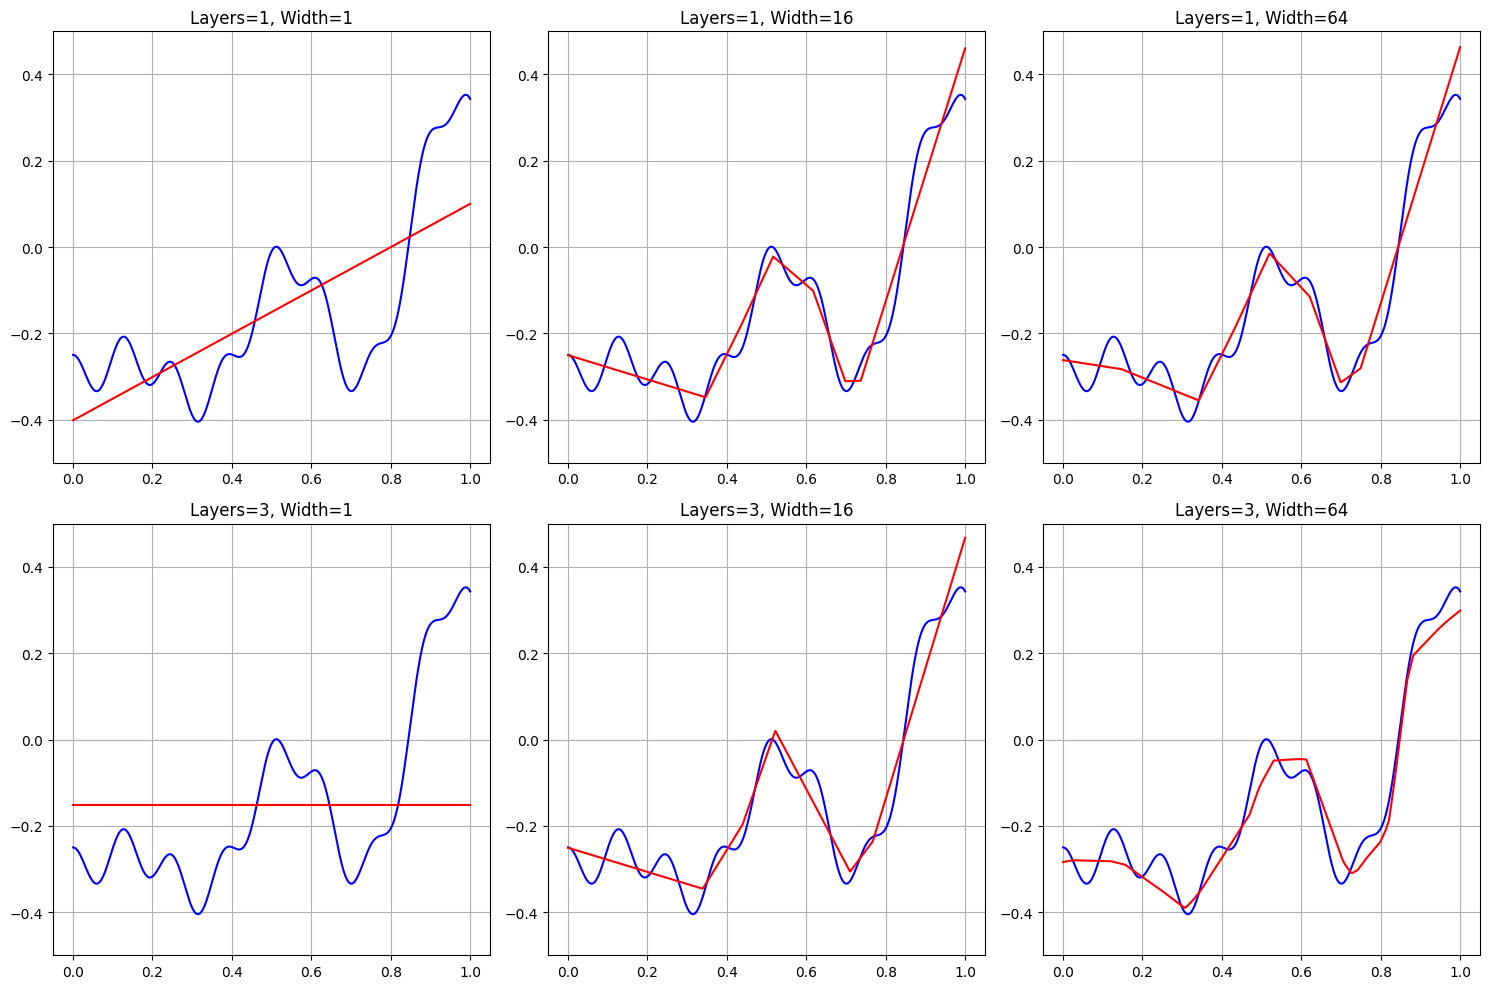

In [14]:
_, arr = plt.subplots(2, 3, figsize=(15, 10))

for i, num_hidden_layers in enumerate([1, 3]):
    for j, width in enumerate([1, 16, 64]):
        ax = arr[i, j]

        ax.plot(x, fs, label="True Function", color="blue")
        ax.plot(x, y_preds[(num_hidden_layers, width)],
                label="Prediction", color="red")

        ax.set_title(f"Layers={num_hidden_layers}, Width={width}")
        ax.set_ylim([-0.5, 0.5])
        ax.grid()

plt.tight_layout()
plt.show()

Discussion:

At layers=1 and width=1, model is practically a single ReLU unit and therefore is almost linear and cannot capture curvature. Therefore it's severely underfitting.

Although still underfitting, model improves performance as we increase width from 1 to 16 and 64, because wider networks can create more piecewise linear regions and better approximate nonlinear functions.

Increasing depth from 1 to 3 layers further improves performance when width is sufficient (16 or 64). Deeper networks allow hierarchical composition of features, enabling more complex function approximations. However, depth does not compensate for extremely small width (width=1), where the network remains severely underfitted.

In [16]:
# y_preds = {}

# for num_hidden_layers in [1, 3]:
#   for width in [1, 16, 64]:
#     _, y_pred = train_model(x[:, None], fs, width=width, num_hidden_layers=num_hidden_layers, activation=nn.Sigmoid)
#     y_preds[(num_hidden_layers, width)] = y_pred


# _, arr = plt.subplots(2, 3, figsize=(15, 10))

# for i, num_hidden_layers in enumerate([1, 3]):
#     for j, width in enumerate([1, 16, 64]):
#         ax = arr[i, j]

#         ax.plot(x, fs, label="True Function", color="blue")
#         ax.plot(x, y_preds[(num_hidden_layers, width)],
#                 label="Prediction", color="red")

#         ax.set_title(f"Layers={num_hidden_layers}, Width={width}")
#         ax.set_ylim([-0.5, 0.5])
#         ax.grid()

# plt.tight_layout()
# plt.show()